In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
df = pd.read_csv('Telco_customer_churn.csv')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
# Data cleaning---- 
# Converting Total Charges to numeric

df['Total Charges'] = pd.to_numeric(df['Total Charges'],errors='coerce') 

In [23]:
df['Churn Value'].value_counts()   #  0  -> Stayed  ,1  -> Churned

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [27]:
#Dropping customer Id as it is not relevant for the analysis

df = df.drop('CustomerID',axis=1)

In [30]:
# Encoding categorical features

df  = pd.get_dummies(df,drop_first=True)

df.head()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV,City_Acton,...,Churn Reason_Lack of self-service on Website,Churn Reason_Limited range of services,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction
0,1,90003,33.964131,-118.272783,2,53.85,1,86,3239,False,...,False,False,False,False,False,False,False,False,False,False
1,1,90005,34.059281,-118.307420,2,70.70,1,67,2701,False,...,False,False,False,True,False,False,False,False,False,False
2,1,90006,34.048013,-118.293953,8,99.65,1,86,5372,False,...,False,False,False,True,False,False,False,False,False,False
3,1,90010,34.062125,-118.315709,28,104.80,1,84,5003,False,...,False,False,False,True,False,False,False,False,False,False
4,1,90015,34.039224,-118.266293,49,103.70,1,89,5340,False,...,False,False,False,False,False,False,False,False,False,False


In [31]:
X = df.drop('Churn Value',axis=1)
y = df['Churn Value']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [32]:
# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
# --------------- Logistic  Regression Model ---------------------------#

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

print('Classification Report - Logistic Regression:\n\n',classification_report(y_test,y_pred))
print('Confusion Matrix:\n\n',confusion_matrix(y_test,y_pred))

Classification Report - Logistic Regression:

               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1035
           1       0.97      0.97      0.97       374

    accuracy                           0.99      1409
   macro avg       0.98      0.98      0.98      1409
weighted avg       0.99      0.99      0.99      1409

Confusion Matrix:

 [[1025   10]
 [  10  364]]


In [42]:
# Random Forest Model

rfm = RandomForestClassifier(n_estimators=200,random_state=42)
rfm.fit(X_train,y_train)

y_pred_rfm = rfm.predict(X_test)

print('Classification Report - Random Forest Classifier:\n\n',classification_report(y_test,y_pred_rfm))
print('Confusion Matrix:\n\n',confusion_matrix(y_test,y_pred_rfm))

Classification Report - Random Forest Classifier:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

Confusion Matrix:

 [[1035    0]
 [   1  373]]


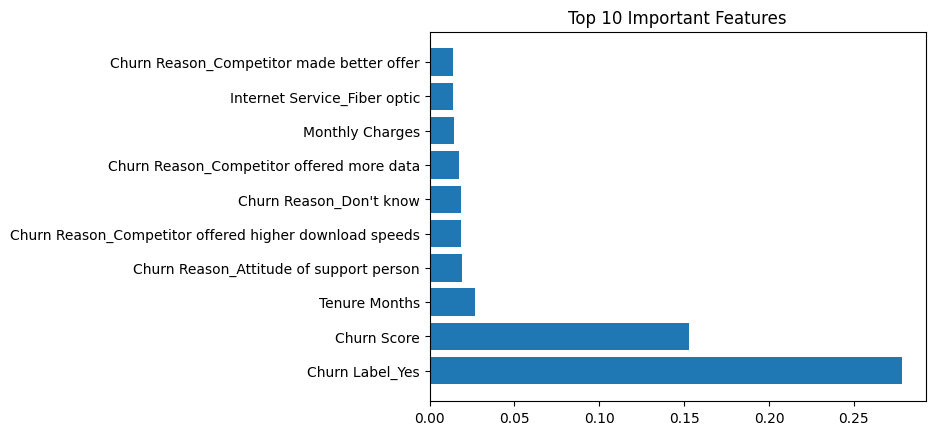

In [44]:
import matplotlib.pyplot as plt

importances = rfm.feature_importances_
features = X.columns

feat_df = pd.DataFrame({"Feature": features, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(10)

plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Top 10 Important Features")
plt.show()


In [45]:
# Applying ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


C:\Users\lijoj\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6916 - loss: 0.5509 - val_accuracy: 0.7879 - val_loss: 0.4334
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9286 - loss: 0.2017 - val_accuracy: 0.8580 - val_loss: 0.3496
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9958 - loss: 0.0264 - val_accuracy: 0.8713 - val_loss: 0.3234
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9996 - loss: 0.0059 - val_accuracy: 0.8722 - val_loss: 0.3143
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.8749 - val_loss: 0.3106
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8713 - val_loss: 0.3088
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 9.8103e-04 - val_accuracy: 0.8713 - val_loss: 0.3083
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 6.8147e-04 - 

In [46]:
ann.evaluate(X_test, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8531 - loss: 0.5280


[0.5279740691184998, 0.853087306022644]